In [467]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [468]:
def f(t: float, z: np.ndarray) -> np.ndarray:
    r = np.ndarray(3)
    r[0] = -0.04*z[0] + 10**4 * z[1]*z[2]
    r[1] = 0.04*z[0] - 10**4 * z[1]*z[2] - 3*10**7 * z[1]**2
    r[2] = 3 * 10**7 * z[1]**2
    return r

In [ ]:
# Butcher-Tableau RADAUIIA
A = np.array([
    [(88-7*np.sqrt(6))/360,       (296-169*np.sqrt(6))/1800, (-2+3*np.sqrt(6))/225],
    [(296+169*np.sqrt(6))/1800,   (88+7*np.sqrt(6))/360,     (-2-3*np.sqrt(6))/225],
    [(16-np.sqrt(6))/36,          (16+np.sqrt(6))/36,                          1/9]
])
b = np.array([(16-np.sqrt(6))/36, (16+np.sqrt(6))/36, 1/9])
c = np.array([(4-np.sqrt(16))/10, (4+np.sqrt(16))/10, 1])

S = np.array([
    [0.0944, -0.14126+0.03003j, -0.14126-0.03003j],
    [0.2501, 0.20413-0.38294j,   0.20413+0.38294j],
    [1,             1,                          1]
])

lam = np.array([
    [0.27489,   0,        0],
    [0, 0.16256-0.18495j, 0],
    [0, 0, 0.16256+0.18495j]
])

# Butcher-Tableau RK4
A4 = np.array([
    [ 0,  0,  0, 0],
    [1/2, 0,  0, 0],
    [ 0, 1/2, 0, 0],
    [ 0,  0,  1, 1]
])
b4 = np.array([1/6, 1/3, 1/3, 1/6])
c4 = np.array([ 0,  1/2, 1/2,  1])

T = np.linspace(0, 4, 400)  # Zeitintervall
u0 = np.array([1,0,0])  # Anfangswert

exact_sol = np.exp(5 * T)

In [ ]:
def rk_implicit(f: callable, A: np.array, b: np.array, c: np.array, u0: np.array, T: np.array) -> np.array:
    s = A.shape[0]
    n = T.shape[0]
    y = np.zeros((n, len(u0)))
    y[0] = u0

    for m in range(n-1):
        h = T[m+1]-T[m]
        k_guess = np.zeros((s, len(u0)))

        def residual(k_flat: np.array):
            k = k_flat.reshape((s, len(u0)))
            res = np.zeros_like(k)

            for i in range(s):
                res[i] = k[i] - f(T[m] + c[i] * h, y[m] + h * A[i, :] @ k)

            return res.flatten()
        
        k_flat_sol = scipy.optimize.fsolve(residual, k_guess, xtol=1e-10)

        k_sol = k_flat_sol.reshape((s, len(u0)))
        
        y[m+1] = y[m] + h * b @ k_sol

    return y


def runge_kutta(f: callable, initialwert: np.ndarray, T: np.ndarray, A: np.array, b, c) -> np.ndarray:
    s = A.shape[0]  # Finde die Stufe des RK-Verfahrens
    n = T.shape[0]  # Berechne die Anzahl an Zeitschritten
    y = np.zeros((n, len(initialwert))) # Bereite den Lösungsvektor vor als Matrix
    y[0] = initialwert  # Füge die Anfangswerte in den Lösungsvektor ein

    for m in range(n-1):
        h = T[m+1]-T[m]
        k = np.zeros((s,len(initialwert)))

        for i in range (0, s):
            k[i] = f(T[m] + c[i] * h, y[m] + h * A[i, :] @ k[:])    # S. Rannacher-Skript oder das derzeitige Num1-Skript

        y[m+1] = y[m] + h * b[:] @ k[:]

    return y
        

def rk_implicit_optimized(f: callable, lam: np.array, S:np.array, b: np.array, c: np.array, u0: np.array, T: np.array):
    

/tmp/ipykernel_1042/2703745292.py:20: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  k_flat_sol = scipy.optimize.fsolve(residual, k_guess, xtol=1e-10)
/tmp/ipykernel_1042/2703745292.py:20: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  k_flat_sol = scipy.optimize.fsolve(residual, k_guess, xtol=1e-10)
/tmp/ipykernel_1042/1019135202.py:3: RuntimeWarning: overflow encountered in scalar multiply
  r[0] = -0.04*z[0] + 10**4 * z[1]*z[2]
/tmp/ipykernel_1042/1019135202.py:4: RuntimeWarning: overflow encountered in scalar multiply
  r[1] = 0.04*z[0] - 10**4 * z[1]*z[2] - 3*10**7 * z[1]**2
/tmp/ipykernel_1042/1019135202.py:4: RuntimeWarning: overflow encountered in scalar power
  r[1] = 0.04*z[0] - 10**4 * z[1]*z[2] - 3*10**7 * z[1]**2
/tmp/ipykernel_1042/1019135202.py:4: RuntimeWarning: invalid value encountered in scalar subtract
 

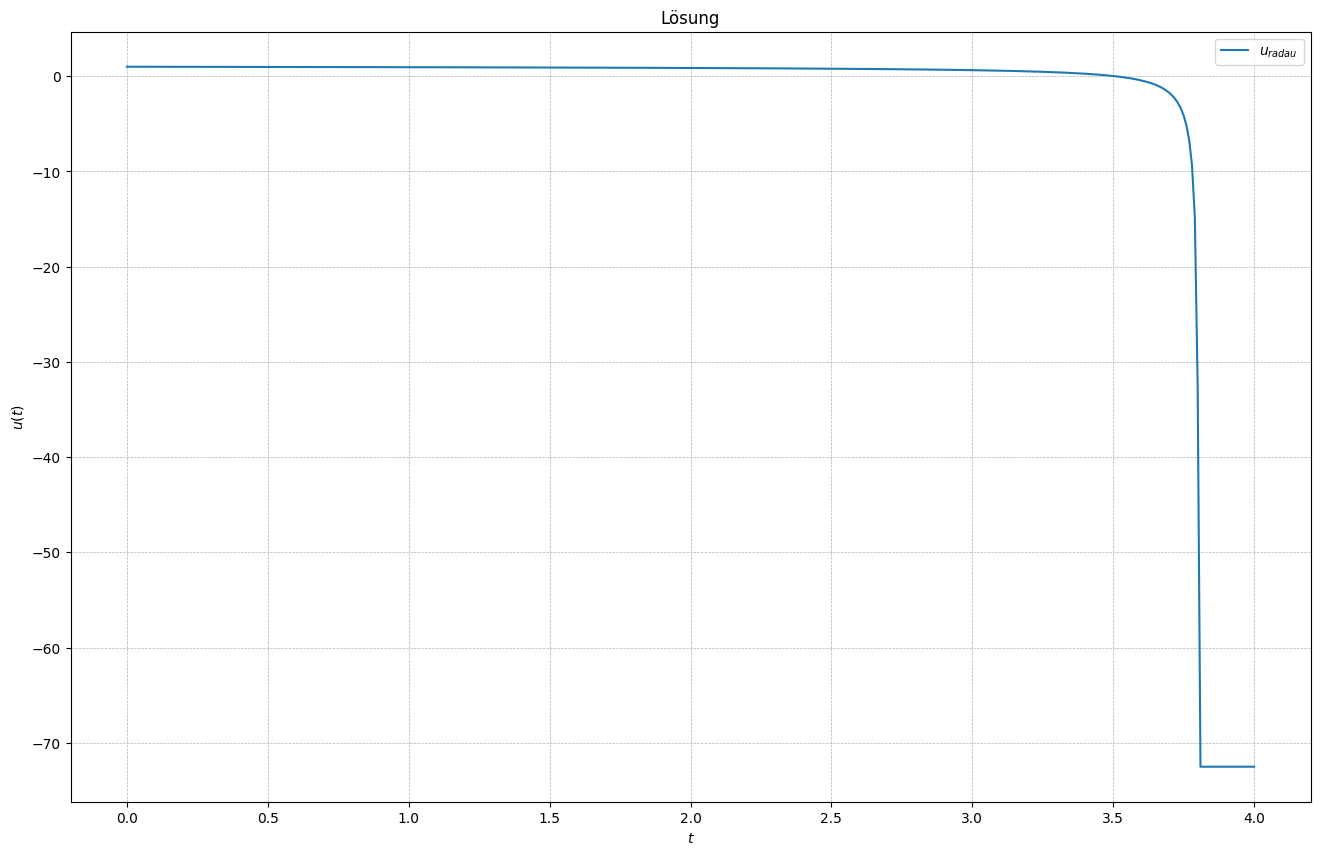

In [471]:
z = rk_implicit(f, A, b, c, u0, T)
zrk4 = runge_kutta(f, u0, T, A4, b4, c4)

error = np.abs(z[:,0] - exact_sol)
errorrk4 = np.abs(zrk4[:,0] - exact_sol)

plt.figure(figsize=(16, 10))
plt.plot(T, z[:,0], label='$u_{radau}$')
#plt.plot(T, zrk4[:,0], label='$u_{RK4}$')
#plt.plot(T, error, label="Error")
#plt.plot(T, errorrk4, label="Error RK4")
plt.xlabel("$t$")
plt.ylabel("$u(t)$")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.title("Lösung")
plt.show()